## Section 1 - Environment Setup and Dependency Installation

In [ ]:
!pip install unsloth -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 136.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

## Section 2 — Library Imports, Experimental Reproducibility, and Configuration

In [ ]:
from unsloth import FastLanguageModel

import os
import re
import json
import warnings
import torch
import gc
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
import random
import numpy as np
import matplotlib.patches as mpatches

from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches
from decimal import Decimal, InvalidOperation
from pathlib import Path
from tqdm import tqdm

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Reproducibility Seed Setting

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

transformers.logging.set_verbosity_error()

### Main Folder Setting

In [ ]:
OUTPUTDIR = "/content/drive/MyDrive/Dataset Skripsi/Result Baseline Evaluation Dual Prompt Full Size"
CHARTSDIR = os.path.join(OUTPUTDIR, "charts")

os.makedirs(OUTPUTDIR, exist_ok=True)
os.makedirs(CHARTSDIR, exist_ok=True)

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Dataset Skripsi/dataset/test/Full Size Test Set - V3/GSM8K Test Set.json"

### Inference and Chart Static Variable

In [ ]:
ENCOLOR = "#4A90D9"
IDCOLOR = "#E74C3C"
STRATA = ["L1", "L2", "L3"]

MAX_SEQ_LENGTH = 2048
LOAD_IN_4BIT = False

GENERATION_CONFIG = {
    "max_new_tokens": 1024,
    "do_sample": False,
    "use_cache": True,
}

## Section 3 - Utils & Data Preprocessing

In [ ]:
def normalize_number(text):
    """Normalisasi jawaban numerik sederhana untuk exact-match GSM8K."""
    if text is None:
        return None

    text = str(text).strip()

    text = text.replace("$", "")
    text = text.replace("Rp.", "")
    text = text.replace("Rp", "")
    text = text.replace("\\,", "")
    text = text.replace(",", "")
    text = text.replace("%", "")
    text = text.strip().rstrip(".")

    text = re.sub(r"(?i)\b(orang|buah|kali|rupiah|unit|hari|jam|menit)\b", "", text)
    text = text.strip()

    if re.fullmatch(r"-?\d+/\d+", text):
        numerator, denominator = text.split("/")
        if denominator != "0":
            value = Decimal(numerator) / Decimal(denominator)
            return format(value.normalize(), "f")

    try:
        value = Decimal(text)
        return format(value.normalize(), "f")
    except (InvalidOperation, ValueError):
        return text.lower()


def extract_answer(text):
    """
    Prioritas extraction:
    1. \\boxed{...}
    4. #### ...
    5. Angka terakhir sebagai fallback
    """
    if text is None:
        return None, "missing"

    text = str(text).strip()

    patterns = [
        (r"\\boxed\{([^{}]+)\}", "boxed"),
        (r"(?im)^\s*####\s*([^\n]+)", "gsm8k_marker"),
    ]

    for pattern, method in patterns:
        matches = re.findall(pattern, text)

        valid_matches = [m.strip() for m in matches if m.strip() and re.search(r"\d", m)]
        if valid_matches:
            return valid_matches[-1], method

    numbers = re.findall(r"-?\d+(?:[.,]\d+)?(?:/\d+)?", text)
    if numbers:
        return numbers[-1].strip(), "last_number_fallback"

    return None, "not_found"


def is_correct(raw_output, ground_truth):
    prediction, extraction_method = extract_answer(raw_output)

    normalized_prediction = normalize_number(prediction)
    normalized_ground_truth = normalize_number(ground_truth)

    correct = (
        normalized_prediction is not None
        and normalized_prediction == normalized_ground_truth
    )

    return {
        "prediction": prediction,
        "normalized_prediction": normalized_prediction,
        "normalized_ground_truth": normalized_ground_truth,
        "extraction_method": extraction_method,
        "correct": correct,
    }


def clear_vram(model=None, tokenizer=None):
    if model is not None:
        del model
    if tokenizer is not None:
        del tokenizer

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Section 4 - System Prompts, Dataset Loading & Inference Engine

### Prompts

In [ ]:
SYSTEM_PROMPT_EN = r"""
You are a mathematical reasoning assistant.

Solve the problem carefully, step by step.
On the final line, write only the final numerical answer in this format:
\boxed{value}
"""

SYSTEM_PROMPT_ID = r"""
Anda adalah asisten penalaran matematika.

Selesaikan soal dengan cermat secara bertahap.
Pada baris terakhir, tuliskan hanya jawaban numerik akhir dengan format:
\boxed{nilai}
"""

### Dataset Loading

In [ ]:
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    raw_dataset = json.load(f)

required_fields = {"question", "translated_question", "answer", "stratum"}

for idx, item in enumerate(raw_dataset):
    missing = required_fields - set(item.keys())
    if missing:
        raise ValueError(f"Data indeks {idx} tidak memiliki field: {missing}")

df_test = pd.DataFrame(raw_dataset)

df_test["question"] = df_test["question"].astype(str).str.strip()
df_test["translated_question"] = df_test["translated_question"].astype(str).str.strip()
df_test["answer"] = df_test["answer"].astype(str).str.strip()
df_test["stratum"] = df_test["stratum"].astype(str).str.strip()

if not set(df_test["stratum"].unique()).issubset(set(STRATA)):
    raise ValueError(
        f"Strata tidak valid: {sorted(df_test['stratum'].unique())}"
    )

full_q_en = df_test["question"].tolist()
full_q_id = df_test["translated_question"].tolist()
full_answers = df_test["answer"].tolist()
full_strata = df_test["stratum"].tolist()

### Model Loader

In [ ]:
def load_model_for_inference(model_name):
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=LOAD_IN_4BIT,
    )

    FastLanguageModel.for_inference(model)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

### Engine

In [ ]:
def run_inference(
    model,
    tokenizer,
    questions,
    system_prompt,
    batch_size=16,
    max_new_tokens=1024,
    desc="Inference",
):
    """
    Greedy decoding yang konsisten.
    Output dipotong menggunakan panjang batch ter-padding,
    karena tokenizer menggunakan left padding.
    """

    model.eval()
    tokenizer.padding_side = "left"

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    all_outputs = []

    for start_idx in tqdm(
        range(0, len(questions), batch_size),
        desc=desc,
    ):
        batch_questions = questions[start_idx : start_idx + batch_size]

        batch_texts = [
            tokenizer.apply_chat_template(
                [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": question.strip()},
                ],
                tokenize=False,
                add_generation_prompt=True,
            )
            for question in batch_questions
        ]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
        ).to(model.device)

        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=True,
            )

        prompt_length = inputs.input_ids.shape[1]
        generated_tokens = outputs[:, prompt_length:]

        decoded_outputs = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True,
        )

        all_outputs.extend(output.strip() for output in decoded_outputs)

        del inputs, outputs, generated_tokens

    return all_outputs

## Section 5 - Evaluation Pipeline

In [ ]:
def evaluate_and_save(
    questions,
    raw_outputs,
    ground_truths,
    strata_list,
    output_prefix,
    language,
    model_name,
    prompt_name,
):
    if not (
        len(questions)
        == len(raw_outputs)
        == len(ground_truths)
        == len(strata_list)
    ):
        raise ValueError("Panjang questions, outputs, answers, dan strata harus sama.")

    records = []

    for question, raw_output, answer, stratum in zip(
        questions,
        raw_outputs,
        ground_truths,
        strata_list,
    ):
        result = is_correct(raw_output, answer)

        records.append(
            {
                "model": model_name,
                "language": language,
                "prompt_name": prompt_name,
                "question": question,
                "raw_output": raw_output,
                "extracted_answer": result["prediction"],
                "normalized_prediction": result["normalized_prediction"],
                "ground_truth": answer,
                "normalized_ground_truth": result["normalized_ground_truth"],
                "extraction_method": result["extraction_method"],
                "stratum": stratum,
                "correct": result["correct"],
            }
        )

    df_results = pd.DataFrame(records)

    output_jsonl = f"{output_prefix}.jsonl"
    output_xlsx = f"{output_prefix}.xlsx"
    output_csv = f"{output_prefix}.csv"

    df_results.to_json(
        output_jsonl,
        orient="records",
        lines=True,
        force_ascii=False,
    )
    df_results.to_excel(output_xlsx, index=False)
    df_results.to_csv(output_csv, index=False, encoding="utf-8-sig")

    accuracy = df_results["correct"].mean()

    per_stratum = (
        df_results.groupby("stratum")["correct"]
        .mean()
        .reindex(STRATA, fill_value=0.0)
        .to_dict()
    )

    extraction_stats = (
        df_results["extraction_method"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    print(f"\nModel        : {model_name}")
    print(f"Bahasa         : {language}")
    print(f"Prompt         : {prompt_name}")
    print(f"Akurasi        : {accuracy * 100:.2f}%")
    print("Akurasi strata :")
    for stratum, score in per_stratum.items():
        print(f"  {stratum}: {score * 100:.2f}%")

    print("Metode ekstraksi jawaban (%):")
    print(extraction_stats)

    return {
        "accuracy": accuracy,
        "per_stratum": per_stratum,
        "extraction_stats": extraction_stats,
        "dataframe": df_results,
    }

## Part 6 - General Evaluation Model (Instruct)

In [ ]:
MODEL_GENERAL = "unsloth/Qwen2.5-1.5B-Instruct"
SAFE_GENERAL = "Qwen2.5-1.5B-Instruct"

model_dir_general = os.path.join(OUTPUTDIR, SAFE_GENERAL)
os.makedirs(model_dir_general, exist_ok=True)

model_instruct, tokenizer_instruct = load_model_for_inference(MODEL_GENERAL)

==((====))==  Unsloth 2026.7.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

### Indonesian (Instruct)

In [ ]:
raw_id_general = run_inference(
    model=model_instruct,
    tokenizer=tokenizer_instruct,
    questions=full_q_id,
    system_prompt=SYSTEM_PROMPT_ID,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="General | Indonesia",
)

General | Indonesia: 100%|██████████| 83/83 [44:45<00:00, 32.36s/it]


In [ ]:
res_id_general = evaluate_and_save(
    questions=full_q_id,
    raw_outputs=raw_id_general,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_general, "indonesian_id_cot"),
    language="Bahasa Indonesia",
    model_name=SAFE_GENERAL,
    prompt_name="ID-CoT",
)


Model        : Qwen2.5-1.5B-Instruct
Bahasa         : Bahasa Indonesia
Prompt         : ID-CoT
Akurasi        : 48.37%
Akurasi strata :
  L1: 55.09%
  L2: 43.43%
  L3: 32.67%
Metode ekstraksi jawaban (%):
{'boxed': 58.98, 'last_number_fallback': 41.02}


### English (Instruct)

In [ ]:
raw_en_general = run_inference(
    model=model_instruct,
    tokenizer=tokenizer_instruct,
    questions=full_q_en,
    system_prompt=SYSTEM_PROMPT_EN,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="General | English",
)

General | English: 100%|██████████| 83/83 [38:35<00:00, 27.90s/it]


In [ ]:
res_en_general = evaluate_and_save(
    questions=full_q_en,
    raw_outputs=raw_en_general,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_general, "english_en_cot"),
    language="Bahasa Inggris",
    model_name=SAFE_GENERAL,
    prompt_name="EN-CoT",
)


Model        : Qwen2.5-1.5B-Instruct
Bahasa         : Bahasa Inggris
Prompt         : EN-CoT
Akurasi        : 67.93%
Akurasi strata :
  L1: 74.46%
  L2: 62.92%
  L3: 53.33%
Metode ekstraksi jawaban (%):
{'boxed': 83.24, 'last_number_fallback': 16.76}


### Save Result

In [ ]:
all_results = []

all_results.append(
    {
        "model": SAFE_GENERAL,
        "precision": "full-size",
        "accuracy_id": res_id_general["accuracy"],
        "accuracy_en": res_en_general["accuracy"],
        "per_stratum_id": res_id_general["per_stratum"],
        "per_stratum_en": res_en_general["per_stratum"],
    }
)

clear_vram(model_instruct, tokenizer_instruct)

## Section 7 - Specialist Model Evaluation (Math-Instruct)

In [ ]:
MODEL_MATH = "unsloth/Qwen2.5-Math-1.5B-Instruct"
SAFE_MATH = "Qwen2.5-Math-1.5B-Instruct"

model_dir_math = os.path.join(OUTPUTDIR, SAFE_MATH)
os.makedirs(model_dir_math, exist_ok=True)

model_math, tokenizer_math = load_model_for_inference(MODEL_MATH)

==((====))==  Unsloth 2026.7.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

### Indonesian (Math)

In [ ]:
raw_id_math = run_inference(
    model=model_math,
    tokenizer=tokenizer_math,
    questions=full_q_id,
    system_prompt=SYSTEM_PROMPT_ID,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="Math | Indonesia",
)

Math | Indonesia: 100%|██████████| 83/83 [1:21:28<00:00, 58.90s/it]


In [ ]:
res_id_math = evaluate_and_save(
    questions=full_q_id,
    raw_outputs=raw_id_math,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_math, "indonesian_id_cot"),
    language="Bahasa Indonesia",
    model_name=SAFE_MATH,
    prompt_name="ID-CoT",
)


Model        : Qwen2.5-Math-1.5B-Instruct
Bahasa         : Bahasa Indonesia
Prompt         : ID-CoT
Akurasi        : 27.22%
Akurasi strata :
  L1: 33.00%
  L2: 20.97%
  L3: 20.00%
Metode ekstraksi jawaban (%):
{'boxed': 95.15, 'last_number_fallback': 4.25, 'not_found': 0.61}


### English (Math)

In [ ]:
raw_en_math = run_inference(
    model=model_math,
    tokenizer=tokenizer_math,
    questions=full_q_en,
    system_prompt=SYSTEM_PROMPT_EN,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="Math | English",
)

Math | English: 100%|██████████| 83/83 [46:29<00:00, 33.61s/it]


In [ ]:
res_en_math = evaluate_and_save(
    questions=full_q_en,
    raw_outputs=raw_en_math,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_math, "english_en_cot"),
    language="Bahasa Inggris",
    model_name=SAFE_MATH,
    prompt_name="EN-CoT",
)


Model        : Qwen2.5-Math-1.5B-Instruct
Bahasa         : Bahasa Inggris
Prompt         : EN-CoT
Akurasi        : 85.67%
Akurasi strata :
  L1: 89.53%
  L2: 84.11%
  L3: 72.67%
Metode ekstraksi jawaban (%):
{'boxed': 98.64, 'last_number_fallback': 1.21, 'not_found': 0.15}


### Save Result

In [ ]:
all_results.append(
    {
        "model": SAFE_MATH,
        "precision": "full-size",
        "accuracy_id": res_id_math["accuracy"],
        "accuracy_en": res_en_math["accuracy"],
        "per_stratum_id": res_id_math["per_stratum"],
        "per_stratum_en": res_en_math["per_stratum"],
    }
)

clear_vram(model_math, tokenizer_math)

### Save Baseline Summary

In [ ]:
df_summary = pd.DataFrame(all_results)

df_summary["accuracy_id_pct"] = (df_summary["accuracy_id"] * 100).round(2)
df_summary["accuracy_en_pct"] = (df_summary["accuracy_en"] * 100).round(2)
df_summary["cross_lingual_gap_pct"] = (
    df_summary["accuracy_en_pct"] - df_summary["accuracy_id_pct"]
).round(2)

summary_path = os.path.join(OUTPUTDIR, "baseline_summary_v2.csv")
df_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

display(
    df_summary[
        [
            "model",
            "precision",
            "accuracy_en_pct",
            "accuracy_id_pct",
            "cross_lingual_gap_pct",
        ]
    ]
)

,model,precision,accuracy_en_pct,accuracy_id_pct,cross_lingual_gap_pct
0,Qwen2.5-1.5B-Instruct,full-size,67.93,48.37,19.56
1,Qwen2.5-Math-1.5B-Instruct,full-size,85.67,27.22,58.45


In [ ]:
def audit_generation_length(raw_outputs, max_new_tokens):
    lengths = [len(text.split()) for text in raw_outputs]

    print(f"Jumlah output                : {len(lengths)}")
    print(f"Rata-rata panjang output     : {np.mean(lengths):.2f} kata")
    print(f"Panjang output maksimum      : {np.max(lengths)} kata")

    suspicious = [
        output for output in raw_outputs
        if len(output.split()) > max_new_tokens * 0.75
    ]

    print(f"Output panjang yang dicurigai: {len(suspicious)}")

    return suspicious

In [ ]:
suspected_truncations = audit_generation_length(
    raw_id_general,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 121.47 kata
Panjang output maksimum      : 499 kata
Output panjang yang dicurigai: 0


In [ ]:
suspected_truncations = audit_generation_length(
    raw_en_general,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 182.11 kata
Panjang output maksimum      : 560 kata
Output panjang yang dicurigai: 0


In [ ]:
suspected_truncations = audit_generation_length(
    raw_id_math,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 222.75 kata
Panjang output maksimum      : 1024 kata
Output panjang yang dicurigai: 15


In [ ]:
suspected_truncations = audit_generation_length(
    raw_en_math,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 189.35 kata
Panjang output maksimum      : 697 kata
Output panjang yang dicurigai: 0


## Section 8 - Visualize Result

In [ ]:
def format_model_name(model_name):
    return (
        model_name
        .replace("Qwen2.5-", "Qwen2.5 ")
        .replace("-Instruct-4bit", " 1.5B-Instruct")
        .replace("-Math", "-Math")
    )

In [ ]:
def plot_main_baseline_comparison(df_summary):
    # 1. Menyiapkan Data Dinamis dari df_summary
    labels = []
    inggris_scores = []
    indonesia_scores = []
    chart_data = [] # Untuk return DataFrame (opsional, menjaga fungsi asli)

    for _, row in df_summary.iterrows():
        model_name = format_model_name(row["model"])
        acc_en = row["accuracy_en"] * 100
        acc_id = row["accuracy_id"] * 100

        labels.append(model_name)
        inggris_scores.append(acc_en)
        indonesia_scores.append(acc_id)

        # Simpan untuk return value seperti fungsi lama
        chart_data.append({"Model": model_name, "Bahasa": "Bahasa Inggris", "Akurasi": acc_en})
        chart_data.append({"Model": model_name, "Bahasa": "Bahasa Indonesia", "Akurasi": acc_id})

    x = np.arange(len(labels))

    # 2. Pengaturan Layout Bar (Sama seperti style Matplotlib sebelumnya)
    width = 0.34
    offset = 0.19

    # 3. Palet Warna Baku
    color_en = '#f2c79e'    # Oranye terang
    color_id = '#d2691e'    # Oranye gelap
    text_color = '#777777'
    title_color = '#666666'

    # 4. Membuat Figure dan Axes (Sesuai request: 11, 6)
    fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')

    # 5. Membuat Bar Chart
    rects1 = ax.bar(x - offset, inggris_scores, width, label='Bahasa Inggris', color=color_en)
    rects2 = ax.bar(x + offset, indonesia_scores, width, label='Bahasa Indonesia', color=color_id)

    # 6. Kustomisasi Sumbu (Spines & Ticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    # Pengaturan Sumbu Y
    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel('Akurasi (%)', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='y', colors=text_color)

    # Pengaturan Sumbu X
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=text_color, fontsize=11)
    ax.set_xlabel('Model', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='x', colors=text_color)

    # 7. Menambahkan Label Nilai di Atas Bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            # Gunakan :.1f agar output rapi (misal 67.9) walau hasil kali pecahan
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, color='black')

    autolabel(rects1)
    autolabel(rects2)

    # 8. Menambahkan Judul dan Subjudul
    fig.text(0.5, 0.96, 'Komparasi Akurasi Keseluruhan', ha='center', va='center',
             fontsize=17, fontweight='bold', color=title_color)
    fig.text(0.5, 0.90, 'General vs Math Instruct', ha='center', va='center',
             fontsize=12, color=text_color)

    # 9. Menambahkan Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False,
              handlelength=1, handleheight=1, labelcolor=text_color, fontsize=11)

    # 10. Mengatur Layout, Menyimpan, dan Menampilkan Chart
    plt.tight_layout()
    plt.subplots_adjust(top=0.78)

    # Asumsi CHARTSDIR sudah didefinisikan sebelumnya di global scope Anda
    try:
        save_path = os.path.join(CHARTSDIR, "baseline_v2_komparasi_utama.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    except NameError:
        pass # Akan dilewati jika variabel CHARTSDIR tidak ada di cell ini

    plt.show()

    return pd.DataFrame(chart_data)

In [ ]:
df_chart_main = plot_main_baseline_comparison(df_summary)

### Visualization Per Strata

In [ ]:
def plot_stratum_comparison(result, model_name, filename):
    # 1. Menyiapkan Data Dinamis dari result berdasarkan STRATA
    labels = []
    inggris_scores = []
    indonesia_scores = []
    chart_data = [] # Untuk return DataFrame agar fungsi bawaan tidak error

    # Asumsi variabel STRATA sudah didefinisikan secara global sebelumnya
    for stratum in STRATA:
        acc_en = result["per_stratum_en"][stratum] * 100
        acc_id = result["per_stratum_id"][stratum] * 100

        labels.append(stratum)
        inggris_scores.append(acc_en)
        indonesia_scores.append(acc_id)

        # Simpan untuk return DataFrame
        chart_data.append({"Strata": stratum, "Bahasa": "Bahasa Inggris", "Akurasi": acc_en})
        chart_data.append({"Strata": stratum, "Bahasa": "Bahasa Indonesia", "Akurasi": acc_id})

    x = np.arange(len(labels))

    # 2. Pengaturan Layout Bar
    width = 0.34
    offset = 0.19

    # 3. Palet Warna Baku
    color_en = '#f2c79e'    # Oranye terang
    color_id = '#d2691e'    # Oranye gelap
    text_color = '#777777'
    title_color = '#666666'

    # 4. Membuat Figure dan Axes (Sesuai request: 11, 6)
    fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')

    # 5. Membuat Bar Chart
    rects1 = ax.bar(x - offset, inggris_scores, width, label='Bahasa Inggris', color=color_en)
    rects2 = ax.bar(x + offset, indonesia_scores, width, label='Bahasa Indonesia', color=color_id)

    # 6. Kustomisasi Sumbu (Spines & Ticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    # Pengaturan Sumbu Y
    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel('Akurasi (%)', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='y', colors=text_color)

    # Pengaturan Sumbu X (Label disesuaikan menjadi Strata)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=text_color, fontsize=11)
    ax.set_xlabel('Strata', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='x', colors=text_color)

    # 7. Menambahkan Label Nilai di Atas Bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, color='black')

    autolabel(rects1)
    autolabel(rects2)

    # 8. Menambahkan Judul dan Subjudul (Subjudul menggunakan parameter model_name)
    fig.text(0.5, 0.96, 'Akurasi per Strata', ha='center', va='center',
             fontsize=17, fontweight='bold', color=title_color)
    fig.text(0.5, 0.90, model_name, ha='center', va='center',
             fontsize=12, color=text_color)

    # 9. Menambahkan Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False,
              handlelength=1, handleheight=1, labelcolor=text_color, fontsize=11)

    # 10. Mengatur Layout, Menyimpan, dan Menampilkan Chart
    plt.tight_layout()
    plt.subplots_adjust(top=0.78)

    # Blok try-except agar tidak error jika CHARTSDIR belum di-define di cell yang sama
    try:
        save_path = os.path.join(CHARTSDIR, filename)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    except NameError:
        print(f"Info: Gambar belum disimpan karena CHARTSDIR tidak ditemukan, tapi bisa ditampilkan.")

    plt.show()

    return pd.DataFrame(chart_data)

In [ ]:
result_general = all_results[0]
result_math = all_results[1]

### General Model (Instruct)

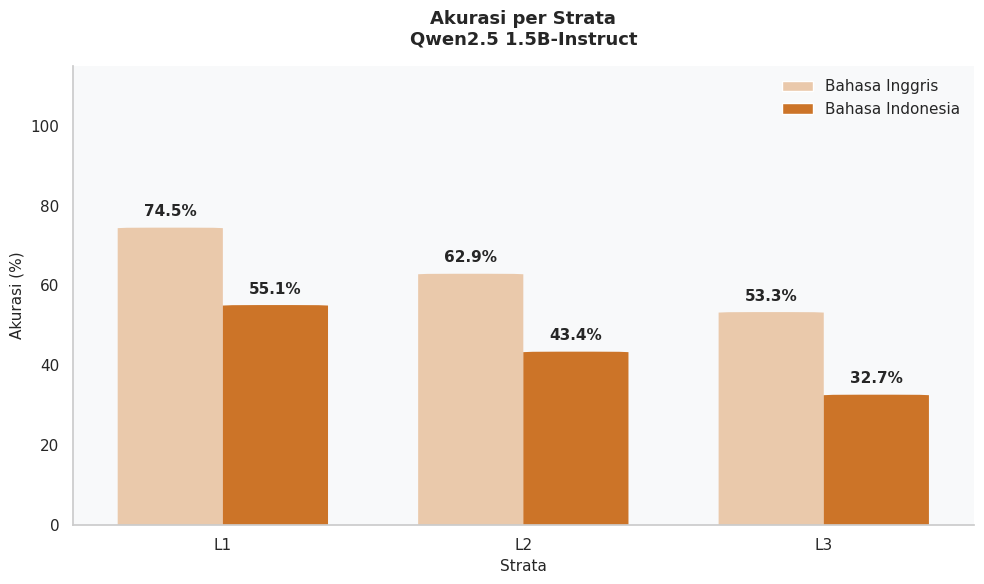

In [ ]:
df_chart_general = plot_stratum_comparison(
    result=result_general,
    model_name="Qwen2.5 1.5B-Instruct",
    filename="baseline_v2_strata_general.png",
)

### General Model (Instruct)

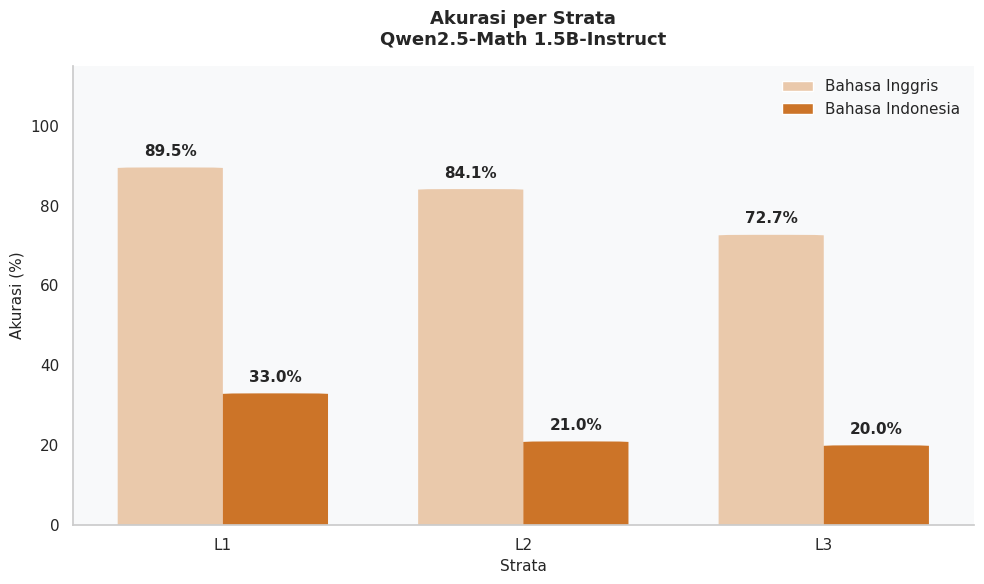

In [ ]:
df_chart_math = plot_stratum_comparison(
    result=result_math,
    model_name="Qwen2.5-Math 1.5B-Instruct",
    filename="baseline_v2_strata_math.png",
)